# Lab 06 — Logistic regression 3 วิธี: numpy vs scikit-learn vs PyTorch
### The same model with numpy, scikit-learn and PyTorch, plus the MLE view

**กลุ่ม:** B perceptron · **อ่านคู่กับสไลด์หน้า:** 32-34, 57-70 · **เวลาโดยประมาณ:** 90 นาที · **Dataset:** nnlab.data.load_breast_cancer_scaled (และ lung toy จากสไลด์สำหรับส่วน MLE)

**ควรทำมาก่อน:** Lab 05 (forward / backward / gradient descent ของ perceptron และ convention ของ X)

## จุดประสงค์การเรียนรู้
เมื่อทำ lab นี้จบ นิสิตจะสามารถ
1. เทรน logistic regression บนข้อมูลจริง (breast cancer, 30 feature) ด้วย `nnlab.Perceptron`, `sklearn.linear_model.LogisticRegression` และ PyTorch แล้วอธิบายได้ว่าทั้งสามคือ**โมเดลเดียวกัน**
2. อ่าน shape ของ parameter ข้ามเครื่องมือ: `w_ (n_x, 1)` ของ numpy, `coef_ (1, n_x)` ของ scikit-learn และ `nn.Linear.weight (1, n_x)` ของ torch และเข้าใจว่า `X @ w` กับ `w.T @ X.T` คือ transpose ของกัน
3. เขียน training loop ของ torch ด้วยมือ (`requires_grad` → `loss.backward()` → อัปเดตใต้ `torch.no_grad()`) และพิสูจน์ด้วย `np.allclose` ว่า autograd ให้ gradient เท่ากับสูตร $dw = \frac{1}{m} X dz^T$ ของ lab05
4. อธิบาย Maximum Likelihood Estimation (สไลด์ p.57-70): Bernoulli → likelihood → log-likelihood และแสดงเป็นตัวเลขว่า $\ln \mathcal{L} = -m \cdot \mathcal{J}$ ดังนั้น gradient ascent บน log-likelihood = gradient descent บน cost
5. เลือก threshold $\tau$ แล้วอธิบาย trade-off ระหว่าง precision กับ recall (ปูทางสู่ lab10)

> **วิธีใช้ notebook นี้:** อ่าน markdown cell ก่อน แล้วรัน code cell ถัดไปด้วย `Shift+Enter` ทีละ cell ตามลำดับ
> ทุก code cell มีคำอธิบายว่าทำอะไรและทำไม ถ้าอยากทดลอง ให้แก้ตัวเลขใน cell แล้วรันซ้ำได้เลย

## เตรียมเครื่องมือ
cell แรกของทุก lab จะ import library ที่ใช้ และตั้ง **seed** ให้ตัวเลขสุ่มเหมือนกันทุกครั้งที่รัน
(ไม่งั้นค่าเริ่มต้นของ weight จะต่างกันทุกรอบ และตัวเลขในหน้าจอจะไม่ตรงกับคำอธิบาย)
lab นี้ใช้ PyTorch ด้วย — `torch.manual_seed` ทำหน้าที่เดียวกับ `set_seed` แต่สำหรับตัวเลขสุ่มฝั่ง torch (ค่าเริ่มต้นของ `nn.Linear`)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import nnlab                      # package ประกอบ lab (ติดตั้งแล้วด้วย uv sync)
except ImportError:                   # เผื่อเปิดด้วย kernel อื่น: เพิ่ม lab/src เข้า path เอง
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
    import nnlab

from nnlab.utils import set_seed
import torch
from torch import nn
torch.manual_seed(463)
rng = set_seed(463)                   # 463 = เลขวิชา CP463
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline
print("numpy", np.__version__, "| nnlab", nnlab.__version__)

numpy 2.2.6 | nnlab 0.1.0


## สัญลักษณ์ในบทนี้
| สัญลักษณ์ | ความหมาย | ใน lab05 / ในโค้ด |
|---|---|---|
| $\theta = (\theta_0, \theta_1, \dots, \theta_{n_x})$ | parameter ของ logit model (สไลด์ p.34) | $\theta_0 = b$, $\theta_j = w_j$ |
| $\pi^{(i)} = \sigma(\theta^T x^{(i)})$ | ความน่าจะเป็นที่โมเดลทายว่า $y^{(i)} = 1$ (สไลด์ p.64) | $a^{(i)} = \hat{y}^{(i)}$ |
| $P(y; \pi) = \pi^{y}(1-\pi)^{1-y}$ | Bernoulli distribution (สไลด์ p.58) | — |
| $\mathcal{L}(\theta; \mathcal{D})$ | **likelihood** ของทั้ง dataset (สไลด์ p.61) — ระวัง สไลด์ใช้ตัว $\mathcal{L}$ เดียวกับ loss ของ lab05 แต่คนละความหมาย | `likelihood` |
| $\ln \mathcal{L}$ | log-likelihood (สไลด์ p.62) | `log_lik` |
| $\tau$ | threshold / cutoff ที่ใช้เปลี่ยนความน่าจะเป็นเป็น class (สไลด์ p.58, 60) | `threshold` |
| `coef_`, `intercept_` | ชื่อ $w$, $b$ ใน scikit-learn — shape `(1, n_x)` และ `(1,)` | `w_ (n_x, 1)`, `b_` |
| `C` | ค่าใน scikit-learn ที่ควบคุม L2 regularization: $C = 1/\lambda$ | `Perceptron(l2=λ)` |
| `nn.Linear(n_x, 1).weight` | $w$ ใน PyTorch — shape `(1, n_x)` | `w_ (n_x, 1)` |

## ขั้นที่ 1 · ข้อมูลจริง: breast cancer 30 feature
lab05 ใช้ตาราง 3 แถวเพื่อให้เห็นตัวเลขทุกตัว คราวนี้ใช้ข้อมูลจริงที่มากับ scikit-learn: ผู้ป่วย 569 คน แต่ละคนมี 30 feature ที่วัดจากภาพเซลล์ (mean radius, mean texture, …)
label $y = 1$ คือ **malignant** (เนื้อร้าย) — เรากำหนดให้ class ที่สนใจเป็น positive เสมอ เพราะ precision / recall ในขั้นที่ 7 นิยามจากมุมของ positive

`load_breast_cancer_scaled` ทำ 2 อย่างให้แล้ว
1. แบ่ง train / test แบบ **stratified** 80 / 20 (สัดส่วน class ในสองชุดเท่ากัน) — test คือข้อมูลที่โมเดล**ไม่เคยเห็น** ใช้วัดผลเท่านั้น
2. **standardize** ทุก feature ให้ค่าเฉลี่ย 0 และ std 1 โดยใช้ $\mu, \sigma$ ที่คำนวณจาก **train เท่านั้น** แล้วนำไปใช้กับ test ด้วย

ทำไมต้อง standardize: feature ดิบมี scale ต่างกันเป็นพันเท่า (cell ถัดไปพิมพ์ให้ดู) ถ้าไม่ปรับ gradient ของ weight ที่คู่กับ feature ค่าใหญ่จะใหญ่ตาม และ learning rate ตัวเดียวจะเล็กไปสำหรับ feature หนึ่งแต่ใหญ่ไปสำหรับอีก feature — gradient descent จะช้ามากหรือ overshoot
ทำไมใช้ $\mu, \sigma$ ของ train: ถ้าเอา test มาคำนวณด้วย ข้อมูล test จะ "รั่ว" เข้าไปในการเทรน ผลที่วัดได้จะดีเกินจริง

> **Convention ที่ใช้ในส่วนนี้: library (pandas / scikit-learn / PyTorch)** — `X` มี shape `(m, n_x)` sample เป็น**แถว**, `y` มี shape `(m,)` และ `Z = X @ W.T + b`

In [2]:
from nnlab.data import load_breast_cancer_scaled
from nnlab.conventions import describe
from sklearn.datasets import load_breast_cancer

X_tr, X_te, y_tr, y_te = load_breast_cancer_scaled()      # X_tr: (m_tr, 30), X_te: (m_te, 30), y: (m,)
feature_names = load_breast_cancer().feature_names          # ชื่อ 30 feature (ใช้ตอนตีความ w)
print("train:", describe(X_tr, "lib"), "| y_tr", y_tr.shape)
print("test :", describe(X_te, "lib"), "| y_te", y_te.shape)
print(f"สัดส่วน malignant (y=1): train {y_tr.mean():.3f} | test {y_te.mean():.3f}   ← stratified จึงเท่ากัน")
print("5 feature แรก:", feature_names[:5].tolist())

raw = load_breast_cancer().data                              # ข้อมูลดิบก่อน standardize (569, 30)
print(f"\nscale ดิบ: mean area = {raw[:, 3].mean():.1f}  vs  mean smoothness = {raw[:, 4].mean():.3f}  → ต่างกัน {raw[:, 3].mean() / raw[:, 4].mean():,.0f} เท่า")
print("หลัง standardize (train): mean ของ 3 feature แรก", X_tr.mean(axis=0)[:3], "| std", X_tr.std(axis=0)[:3])
print("test ใช้ μ, σ ของ train จึงไม่ได้ 0/1 พอดี: mean", X_te.mean(axis=0)[:3], "| std", X_te.std(axis=0)[:3])

train: shape (456, 30) → m=456 samples, n_x=30 features (sample เป็นแถว) | y_tr (456,)
test : shape (113, 30) → m=113 samples, n_x=30 features (sample เป็นแถว) | y_te (113,)
สัดส่วน malignant (y=1): train 0.373 | test 0.372   ← stratified จึงเท่ากัน
5 feature แรก: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

scale ดิบ: mean area = 654.9  vs  mean smoothness = 0.096  → ต่างกัน 6,796 เท่า
หลัง standardize (train): mean ของ 3 feature แรก [-0. -0.  0.] | std [1. 1. 1.]
test ใช้ μ, σ ของ train จึงไม่ได้ 0/1 พอดี: mean [0.0535 0.1259 0.0515] | std [1.0622 0.9819 1.0627]


## ขั้นที่ 2 · วิธีที่ 1: numpy (`Perceptron` จาก lab05)
สไลด์ p.33: perceptron ที่ใช้ sigmoid **คือ** logit model / logistic regression — จึงไม่ต้องเขียนอะไรใหม่ ใช้ `nnlab.perceptron.Perceptron` ที่เราเทียบกับโค้ดของตัวเองไปแล้วใน lab05
ตั้งค่าเหมือนเดิม: เริ่ม $w = 0, b = 0$, $\alpha = 0.1$, 300 epoch, full batch (ใช้ทุก sample ทุก epoch)
`Timer` ของ `nnlab.utils` จับเวลาให้ — เราจะเก็บผลของทุกวิธีไว้ใน dict `results` เพื่อสร้างตารางเปรียบเทียบในขั้นที่ 5
คาดว่า: cost เริ่มที่ $\log 2 = 0.6931$ (ตามที่จำจาก lab05), `w_.shape == (30, 1)` และ accuracy บน test เกิน 0.93

Perceptron(lr=0.1, epochs=300, l2=0.0, fitted=True)
w_.shape = (30, 1) | b_ = -0.4409 | เวลาเทรน 0.012 s
cost epoch 0 = 0.6931 | epoch 299 = 0.072
cost ยังลดอยู่ตอนหยุด (epoch 298 → 299): 6.13e-05 ← ยังไม่ถึง optimum
test: {'tp': 40, 'fp': 3, 'tn': 68, 'fn': 2, 'accuracy': 0.956, 'precision': 0.93, 'recall': 0.952, 'specificity': 0.958, 'f1': 0.941}


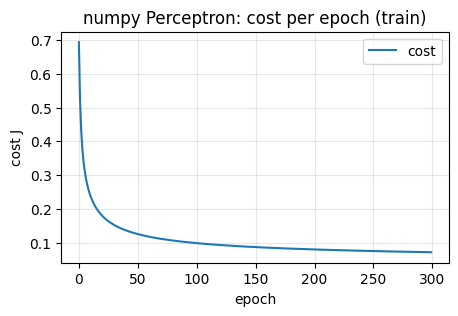

In [3]:
from nnlab.perceptron import Perceptron
from nnlab.utils import Timer
from nnlab.plotting import plot_history

with Timer() as t_np:
    model_np = Perceptron(lr=0.1, epochs=300).fit(X_tr, y_tr)   # รับ X (m, n_x) แล้ว to_deck ภายใน
print(model_np)
print("w_.shape =", model_np.w_.shape, "| b_ =", round(model_np.b_, 4), "| เวลาเทรน", f"{t_np.elapsed:.3f} s")
print("cost epoch 0 =", round(model_np.history_["cost"][0], 4), "| epoch 299 =", round(model_np.history_["cost"][-1], 4))
print("cost ยังลดอยู่ตอนหยุด (epoch 298 → 299):", f"{model_np.history_['cost'][-2] - model_np.history_['cost'][-1]:.2e}", "← ยังไม่ถึง optimum")

rep_np = model_np.evaluate(X_te, y_te)                          # dict จาก nnlab.metrics.binary_report
print("test:", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in rep_np.items()})
results = {"numpy": {**rep_np, "w1": model_np.w_[0, 0], "w2": model_np.w_[1, 0], "w3": model_np.w_[2, 0], "seconds": t_np.elapsed}}

plt.figure(figsize=(5, 3)); plot_history(model_np.history_, title="numpy Perceptron: cost per epoch (train)"); plt.show()

## ขั้นที่ 3 · วิธีที่ 2: scikit-learn `LogisticRegression`
scikit-learn มีโมเดลเดียวกันสำเร็จรูป แต่ค่า default ต่างจากที่เราเขียน 2 จุด
- **regularization**: มี L2 penalty เสมอ ควบคุมด้วย `C` โดย $C = 1/\lambda$ (default `C=1.0` คือ $\lambda = 1$) — `C` ใหญ่ = regularize น้อย
- **optimizer**: ไม่ใช้ gradient descent แต่ใช้ `lbfgs` (วิธี quasi-Newton ที่ใช้ข้อมูลความโค้งของ cost) จึง**ลู่เข้าจนสุด**ในไม่กี่สิบ iteration ไม่ต้องเลือก learning rate

ชื่อ parameter ก็ต่างกัน: `coef_` มี shape `(1, n_x)` (แถวเดียว) และ `intercept_` shape `(1,)` — เทียบกับ `w_ (n_x, 1)` ของเราคือ transpose กัน
`predict_proba` คืน `(m, 2)`: คอลัมน์ 0 = $P(y=0)$, คอลัมน์ 1 = $P(y=1)$ รวมกันได้ 1 เสมอ

In [4]:
from sklearn.linear_model import LogisticRegression
from nnlab.metrics import binary_report

with Timer() as t_sk:
    sk = LogisticRegression().fit(X_tr, y_tr)                   # default: C=1.0 (L2), solver="lbfgs", max_iter=100
print("ลู่เข้าใน", sk.n_iter_[0], "iteration | เวลาเทรน", f"{t_sk.elapsed:.3f} s")
print("coef_.shape =", sk.coef_.shape, "| intercept_ =", sk.intercept_, sk.intercept_.shape)
print("coef_.T.shape =", sk.coef_.T.shape, "== w_.shape ของ numpy", model_np.w_.shape, "→", sk.coef_.T.shape == model_np.w_.shape)

P_sk = sk.predict_proba(X_te)                                   # (m_te, 2)
print("predict_proba shape", P_sk.shape, "| แถวแรก", P_sk[0], "| ทุกแถวรวมได้ 1:", np.allclose(P_sk.sum(axis=1), 1))
rep_sk = binary_report(y_te, sk.predict(X_te))
print("test:", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in rep_sk.items()})

print("\n3 weight แรก  numpy:", model_np.w_.ravel()[:3], "| sklearn:", sk.coef_.ravel()[:3])
print(f"‖w‖  numpy = {np.linalg.norm(model_np.w_):.3f} | sklearn (C=1) = {np.linalg.norm(sk.coef_):.3f}")
results["sklearn"] = {**rep_sk, "w1": sk.coef_[0, 0], "w2": sk.coef_[0, 1], "w3": sk.coef_[0, 2], "seconds": t_sk.elapsed}

ลู่เข้าใน 18 iteration | เวลาเทรน 0.011 s
coef_.shape = (1, 30) | intercept_ = [-0.2862] (1,)
coef_.T.shape = (30, 1) == w_.shape ของ numpy (30, 1) → True
predict_proba shape (113, 2) | แถวแรก [0.9993 0.0007] | ทุกแถวรวมได้ 1: True
test: {'tp': 39, 'fp': 4, 'tn': 67, 'fn': 3, 'accuracy': 0.938, 'precision': 0.907, 'recall': 0.929, 'specificity': 0.944, 'f1': 0.918}

3 weight แรก  numpy: [0.4852 0.5403 0.4737] | sklearn: [0.4339 0.6574 0.4211]
‖w‖  numpy = 2.221 | sklearn (C=1) = 3.805


ทำไมตัวเลขไม่ตรงกับ numpy ทั้งที่เป็นโมเดลเดียวกัน — เพราะ "จุดที่หยุด" ต่างกัน ไม่ใช่โมเดลต่างกัน
- sklearn หยุดที่ optimum ของ **cost + L2 penalty** (`lbfgs` ลู่เข้าจนสุด)
- numpy หยุดที่ epoch 300 ของ gradient descent บน cost ล้วนๆ ซึ่ง**ยังไม่ถึง optimum** (cell ก่อนหน้าแสดงว่า cost ยังลดอยู่) — ข้อมูลชุดนี้เกือบแบ่งด้วยเส้นตรงได้สมบูรณ์ ถ้าเทรนต่อไปเรื่อยๆ $\|w\|$ จะโตขึ้นไม่หยุด การหยุดก่อนจึงเป็นการ regularize โดยปริยาย (แบบฝึกหัด 6.2 ท้าย lab ให้ดูว่า `C=1e6` กับ `C=0.01` เปลี่ยน $\|w\|$ อย่างไร)

`nnlab.baselines.SklearnLogReg` ห่อ `LogisticRegression` ให้มี interface เดียวกับ `Perceptron` (`w_` เป็น `(n_x, 1)`, `predict_proba` คืน `(m,)`, มี `evaluate`) — cell ถัดไปยืนยันว่าได้ค่าเดียวกับการเรียก sklearn ตรงๆ

In [5]:
from nnlab.baselines import SklearnLogReg

sk_wrapped = SklearnLogReg().fit(X_tr, y_tr)                    # C=1.0 เหมือน default
print(sk_wrapped)
print("w_.shape =", sk_wrapped.w_.shape, "| b_ =", round(sk_wrapped.b_, 4))
assert np.allclose(sk_wrapped.w_, sk.coef_.T) and np.isclose(sk_wrapped.b_, sk.intercept_[0])
assert np.allclose(sk_wrapped.predict_proba(X_te), P_sk[:, 1])       # (m,) = คอลัมน์ 1 ของ (m, 2)
print("predict_proba shape", sk_wrapped.predict_proba(X_te).shape, "| evaluate ตรงกับ sklearn ตรงๆ:", sk_wrapped.evaluate(X_te, y_te) == rep_sk)

SklearnLogReg(LogisticRegression(max_iter=1000, random_state=463))
w_.shape = (30, 1) | b_ = -0.2862
predict_proba shape (113,) | evaluate ตรงกับ sklearn ตรงๆ: True


## ขั้นที่ 4 · วิธีที่ 3: PyTorch
`torch.Tensor` คือ `ndarray` ที่เพิ่มความสามารถ 2 อย่าง: รันบน GPU ได้ และ **autograd** — ถ้าตั้ง `requires_grad=True` torch จะจำ computational graph (สไลด์ p.22-24) ของทุกการคำนวณ แล้ว `loss.backward()` จะไล่ chain rule ย้อนกลับให้เอง เราไม่ต้องเขียนสูตร $dz, dw, db$ อีก
สิ่งที่ต้องรู้เรื่อง layout: torch วาง sample เป็น**แถว** เหมือน scikit-learn ดังนั้น
$$z_{(m \times 1)} = X_{(m \times n_x)}\, w_{(n_x \times 1)} + b \qquad \text{เทียบกับสไลด์} \qquad Z_{(1 \times m)} = w^T X_{(n_x \times m)} + b$$
สองนิพจน์นี้เป็น transpose ของกัน: $X w = (w^T X^T)^T$ — ตัวเลขเดียวกันทุกตัว แค่วางแนวตั้งแทนแนวนอน

### numpy | torch เทียบบรรทัดต่อบรรทัด (หนึ่ง epoch จาก $w = 0$)
สอง cell ถัดไปทำงานเดียวกัน: forward → cost → gradient ที่จุด $w = 0, b = 0$ — cell แรกด้วยสูตรของ lab05 (convention สไลด์) cell ที่สองด้วย autograd (convention torch) แล้ว `assert` ว่า gradient เท่ากัน

> **Convention ที่ใช้ในส่วนนี้: สไลด์ (deck)** — `X` มี shape `(n_x, m)` sample เป็น**คอลัมน์**, `Y` มี shape `(1, m)`, `w` มี shape `(n_x, 1)` และ `Z = w.T @ X + b`

In [6]:
from nnlab.conventions import to_deck
from nnlab.perceptron import forward, backward
from nnlab.losses import binary_cross_entropy

X_d, Y_d = to_deck(X_tr, y_tr)                  # X_d: (n_x, m) = (30, 456), Y_d: (1, m)
n_x, m = X_d.shape
w_np, b_np = np.zeros((n_x, 1)), 0.0            # w_np: (30, 1)

A_np, Z_np = forward(w_np, b_np, X_d)           # Z_np, A_np: (1, m)
J_np = binary_cross_entropy(A_np, Y_d)          # scalar
dw_np, db_np, dz_np = backward(X_d, A_np, Y_d)  # dw_np: (30, 1), db_np: scalar
print("numpy : Z", Z_np.shape, "| cost", round(J_np, 6), "| dw", dw_np.shape, "3 ตัวแรก", dw_np.ravel()[:3], "| db", round(db_np, 6))

numpy : Z (1, 456) | cost 0.693147 | dw (30, 1) 3 ตัวแรก [-0.3541 -0.2159 -0.3602] | db 0.127193


> **Convention ที่ใช้ในส่วนนี้: library (pandas / scikit-learn / PyTorch)** — `X` มี shape `(m, n_x)` sample เป็น**แถว**, `y` มี shape `(m,)` และ `Z = X @ W.T + b`

In [7]:
import torch.nn.functional as F

X_t = torch.tensor(X_tr, dtype=torch.float32)                 # X_t: (m, n_x) = (456, 30) sample เป็นแถว
y_t = torch.tensor(y_tr, dtype=torch.float32)                 # y_t: (m,)
w = torch.zeros(n_x, 1, requires_grad=True)                   # w: (30, 1)  ← บอก torch ให้ติดตาม gradient
b = torch.zeros(1, requires_grad=True)                        # b: (1,)

z = X_t @ w + b                                               # (m, 30) @ (30, 1) + (1,) → z: (m, 1)
assert torch.allclose(z, (w.T @ X_t.T).T)                     # X w == (wᵀ Xᵀ)ᵀ  — layout ต่างกันแต่ตัวเลขเดียวกัน
loss = F.binary_cross_entropy_with_logits(z.squeeze(), y_t)   # z.squeeze(): (m,) ให้ shape ตรงกับ y_t; loss: scalar
loss.backward()                                               # autograd: คำนวณ ∂loss/∂w, ∂loss/∂b ไปเก็บใน .grad

print("torch : z", tuple(z.shape), "| loss", round(loss.item(), 6), "| w.grad", tuple(w.grad.shape), "3 ตัวแรก", w.grad.numpy().ravel()[:3], "| b.grad", round(b.grad.item(), 6))
assert np.isclose(loss.item(), J_np, atol=1e-6)
assert np.allclose(w.grad.numpy(), dw_np, atol=1e-6) and np.isclose(b.grad.item(), db_np, atol=1e-6)
assert np.allclose(z.detach().numpy().T, Z_np, atol=1e-6)     # z (m,1) transpose แล้วเท่ากับ Z (1,m)
print("autograd ให้ gradient เท่ากับสูตร dw = X dzᵀ / m, db = Σdz / m ของ lab05 ✓  (ต่างกันระดับ float32 ≈ 1e-7)")

torch : z (456, 1) | loss 0.693147 | w.grad (30, 1) 3 ตัวแรก [-0.3541 -0.2159 -0.3602] | b.grad 0.127193
autograd ให้ gradient เท่ากับสูตร dw = X dzᵀ / m, db = Σdz / m ของ lab05 ✓  (ต่างกันระดับ float32 ≈ 1e-7)


### training loop ของ torch เขียนเอง 300 epoch
gradient ได้แล้ว เหลือแค่วนซ้ำ มีกติกา 2 ข้อที่ต่างจาก numpy
1. อัปเดต `w -= lr * w.grad` ต้องอยู่ใต้ `with torch.no_grad():` — ไม่งั้น torch จะบันทึกการอัปเดตลง graph ด้วย (เราแค่จะแก้ค่า ไม่ได้อยากหาอนุพันธ์ของการแก้ค่า)
2. torch **สะสม** gradient ใน `.grad` ทุกครั้งที่เรียก `backward()` ต้อง `grad.zero_()` ก่อนรอบถัดไป ไม่งั้น gradient รอบเก่าจะบวกเข้ามา

เราใช้ init, learning rate, จำนวน epoch และ full batch เหมือน numpy ทุกอย่าง จึงคาดว่า $w$ สุดท้ายต้อง**เท่ากับ** `model_np.w_` (ต่างกันแค่ float32 vs float64 ระดับ 1e-6)

In [8]:
lr, epochs = 0.1, 300
w = torch.zeros(n_x, 1, requires_grad=True)                   # w: (30, 1) เริ่มใหม่จากศูนย์
b = torch.zeros(1, requires_grad=True)
cost_torch = []
with Timer() as t_tm:
    for epoch in range(epochs):
        z = X_t @ w + b                                       # forward: (m, 1)
        loss = F.binary_cross_entropy_with_logits(z.squeeze(), y_t)
        loss.backward()                                       # backward: เติม w.grad, b.grad
        with torch.no_grad():                                 # อัปเดตโดยไม่บันทึกลง graph
            w -= lr * w.grad
            b -= lr * b.grad
        w.grad.zero_(); b.grad.zero_()                        # ล้าง gradient สะสม
        cost_torch.append(loss.item())

w_tm = w.detach().numpy()                                     # (30, 1) ออกจาก graph แล้วแปลงเป็น numpy
print("cost epoch 0 =", round(cost_torch[0], 4), "| epoch 299 =", round(cost_torch[-1], 4), "| เวลา", f"{t_tm.elapsed:.3f} s")
print("3 weight แรก  torch-manual:", w_tm.ravel()[:3], "| numpy:", model_np.w_.ravel()[:3])
print("max |w_torch − w_numpy| =", f"{np.abs(w_tm - model_np.w_).max():.2e}", "| |b_torch − b_numpy| =", f"{abs(b.item() - model_np.b_):.2e}")
assert np.allclose(w_tm, model_np.w_, atol=1e-4) and np.isclose(b.item(), model_np.b_, atol=1e-4)
assert np.allclose(cost_torch, model_np.history_["cost"], atol=1e-5)
print("อัลกอริทึมเดียวกัน + init เดียวกัน + lr เดียวกัน + full batch → parameter เดียวกัน ✓")

with torch.no_grad():
    p_tm = torch.sigmoid(torch.tensor(X_te, dtype=torch.float32) @ w + b).squeeze().numpy()   # (m_te,)
rep_tm = binary_report(y_te, (p_tm >= 0.5).astype(int))
print("test:", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in rep_tm.items()})
results["torch-manual"] = {**rep_tm, "w1": w_tm[0, 0], "w2": w_tm[1, 0], "w3": w_tm[2, 0], "seconds": t_tm.elapsed}

cost epoch 0 = 0.6931 | epoch 299 = 0.072 | เวลา 0.015 s
3 weight แรก  torch-manual: [0.4852 0.5403 0.4737] | numpy: [0.4852 0.5403 0.4737]
max |w_torch − w_numpy| = 4.07e-07 | |b_torch − b_numpy| = 2.27e-08
อัลกอริทึมเดียวกัน + init เดียวกัน + lr เดียวกัน + full batch → parameter เดียวกัน ✓
test: {'tp': 40, 'fp': 3, 'tn': 68, 'fn': 2, 'accuracy': 0.956, 'precision': 0.93, 'recall': 0.952, 'specificity': 0.958, 'f1': 0.941}


### ทำไมใช้ `binary_cross_entropy_with_logits` แทน `sigmoid` + `BCELoss`
ทั้งสองคือสูตรเดียวกันทางคณิตศาสตร์ แต่ "with logits" รับ $z$ ตรงๆ แล้วคำนวณ $\log \sigma(z)$ ด้วยสูตรที่ไม่ต้องหา $\sigma(z)$ ก่อน
ปัญหาของการทำสองขั้น: ใน float32 เมื่อ $z$ ใหญ่พอ (cell ถัดไปหาค่าให้) $\sigma(z)$ ถูกปัดเป็น 1.0 พอดี แล้ว $\log(1 - 1.0) = \log 0 = -\infty$ — torch จึงต้อง clamp ค่าไว้ ซึ่งทำให้ loss ผิดจากค่าจริง
cell ถัดไปเทียบที่ $z = 20, y = 0$: loss ที่ถูกคือ $-\log(1 - \sigma(20)) = \log(1 + e^{20}) \approx 20$

In [9]:
zs = torch.arange(10, 30, 0.5)                                            # float32 ตาม default ของ torch
z_sat = zs[torch.sigmoid(zs) == 1.0][0].item()
print(f"σ(z) ใน float32 ปัดเป็น 1.0 พอดีตั้งแต่ z = {z_sat} (σ({z_sat}) = 1 − {np.exp(-z_sat):.1e} เล็กกว่าครึ่งหนึ่งของระยะห่างระหว่างเลข float32 ที่อยู่ติดกันใกล้ 1 ≈ 1.2e-7 ดังนั้น 1 + e^-z ถูกปัดเป็น 1)")
z_big = torch.tensor([20.0]); y_zero = torch.tensor([0.0])
print("σ(20) ใน float32 =", torch.sigmoid(z_big).item(), "← ปัดเป็น 1.0 พอดี")
print("sigmoid + BCELoss        :", F.binary_cross_entropy(torch.sigmoid(z_big), y_zero).item(), "(ค่าที่ clamp ไว้ ไม่ใช่ค่าจริง)")
print("BCEWithLogits            :", F.binary_cross_entropy_with_logits(z_big, y_zero).item())
print("ค่าจริง log(1 + e^20)     :", float(np.log1p(np.exp(20.0))))
print("ใน float64 ของ numpy (lab05) ปัญหาเดียวกันเกิดที่ z ≈ 37 — nnlab.losses.bce_loss จึง clip a ไว้ที่ [1e-12, 1 − 1e-12]")

σ(z) ใน float32 ปัดเป็น 1.0 พอดีตั้งแต่ z = 17.0 (σ(17.0) = 1 − 4.1e-08 เล็กกว่าครึ่งหนึ่งของระยะห่างระหว่างเลข float32 ที่อยู่ติดกันใกล้ 1 ≈ 1.2e-7 ดังนั้น 1 + e^-z ถูกปัดเป็น 1)
σ(20) ใน float32 = 1.0 ← ปัดเป็น 1.0 พอดี
sigmoid + BCELoss        : 100.0 (ค่าที่ clamp ไว้ ไม่ใช่ค่าจริง)
BCEWithLogits            : 20.0
ค่าจริง log(1 + e^20)     : 20.000000002061153
ใน float64 ของ numpy (lab05) ปัญหาเดียวกันเกิดที่ z ≈ 37 — nnlab.losses.bce_loss จึง clip a ไว้ที่ [1e-12, 1 − 1e-12]


### แบบที่ใช้จริง: `nn.Linear` + `nn.BCEWithLogitsLoss` + `torch.optim.SGD`
ในงานจริงไม่มีใครสร้าง `w`, `b` เอง — ใช้ `nn.Linear(30, 1)` ซึ่งเก็บ `weight (1, 30)` และ `bias (1,)` (สังเกต: shape เดียวกับ `coef_` ของ sklearn ไม่ใช่ `(30, 1)` ของเรา — torch คำนวณ `x @ weight.T + bias`)
loop มาตรฐาน `zero_grad → forward → loss → backward → step` ถูกห่อไว้ใน `nnlab.torch_models.TorchTrainer` (เปิด `src/nnlab/torch_models.py` ดูได้ — เป็น loop เดียวกับที่เราเพิ่งเขียน)
`TorchPerceptron(30)` คือ `nn.Linear(30, 1)` ที่คืน logits ยังไม่ผ่าน sigmoid เพื่อใช้กับ `BCEWithLogitsLoss`; `batch_size=None` = full batch; `device="cpu"` เพื่อให้ทุกเครื่องได้ผลเหมือนกัน
ข้อต่างเดียวจาก numpy: `nn.Linear` **สุ่ม** ค่าเริ่มต้นของ weight (ไม่ใช่ศูนย์) cost ที่ epoch 0 จึงไม่ใช่ 0.6931 และ $w$ สุดท้ายจะใกล้แต่ไม่เท่ากับ numpy

In [10]:
from nnlab.torch_models import TorchPerceptron, TorchTrainer

torch.manual_seed(463)                                        # ให้ค่าเริ่มต้นสุ่มของ nn.Linear เหมือนกันทุกครั้งที่รัน
net = TorchPerceptron(n_in=30)                                # = nn.Linear(30, 1) คืน logits (m,)
print(net)
print("weight.shape =", tuple(net.linear.weight.shape), "(เหมือน coef_ ของ sklearn) | bias.shape =", tuple(net.linear.bias.shape))
print("weight เริ่มต้นสุ่ม 3 ตัวแรก:", net.linear.weight.detach().numpy().ravel()[:3], "← ไม่ใช่ศูนย์")

trainer = TorchTrainer(net, loss="bce", optimizer="sgd", lr=0.1, epochs=300, batch_size=None, device="cpu")
with Timer() as t_tn:
    trainer.fit(X_tr, y_tr)                                   # รับ numpy (m, n_x) แปลงเป็น tensor ให้เอง
print(trainer)
print("cost epoch 0 =", round(trainer.history_["cost"][0], 4), "(ไม่ใช่ 0.6931 เพราะ init สุ่ม) | epoch 299 =", round(trainer.history_["cost"][-1], 4), "| เวลา", f"{t_tn.elapsed:.3f} s")
w_tn = net.linear.weight.detach().numpy().T                   # (1, 30) → (30, 1) ให้เทียบกับ numpy ได้
print("3 weight แรก  torch-nn:", w_tn.ravel()[:3], "| numpy:", model_np.w_.ravel()[:3], "| max |Δ| =", f"{np.abs(w_tn - model_np.w_).max():.3f}")
rep_tn = trainer.evaluate(X_te, y_te)
print("test:", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in rep_tn.items()})
results["torch-nn"] = {**rep_tn, "w1": w_tn[0, 0], "w2": w_tn[1, 0], "w3": w_tn[2, 0], "seconds": t_tn.elapsed}

TorchPerceptron(
  (linear): Linear(in_features=30, out_features=1, bias=True)
)
weight.shape = (1, 30) (เหมือน coef_ ของ sklearn) | bias.shape = (1,)
weight เริ่มต้นสุ่ม 3 ตัวแรก: [-0.1631  0.0276  0.0948] ← ไม่ใช่ศูนย์


TorchTrainer(TorchPerceptron, loss=bce, optimizer=sgd, lr=0.1, epochs=300, batch_size=None, device=cpu)
cost epoch 0 = 0.6998 (ไม่ใช่ 0.6931 เพราะ init สุ่ม) | epoch 299 = 0.0725 | เวลา 1.014 s
3 weight แรก  torch-nn: [0.3406 0.5317 0.5841] | numpy: [0.4852 0.5403 0.4737] | max |Δ| = 0.177
test: {'tp': 41, 'fp': 3, 'tn': 68, 'fn': 1, 'accuracy': 0.965, 'precision': 0.932, 'recall': 0.976, 'specificity': 0.958, 'f1': 0.953}


## ขั้นที่ 5 · ตารางเปรียบเทียบ 4 การเทรน
รวมผลทั้งหมดใน `pandas.DataFrame` แถวละวิธี — สังเกต 3 อย่าง
1. metric บน test ทุกวิธีอยู่ใกล้กันมาก (ต่างกันแค่ผู้ป่วย 1-3 คนจาก 113) — เพราะเป็น**โมเดลเดียวกัน**
2. `numpy` กับ `torch-manual` ได้ weight เท่ากันทุกหลัก (อัลกอริทึมเดียวกันเป๊ะ) ส่วน `torch-nn` ใกล้เคียง (init ต่าง) และ `sklearn` ต่างมากที่สุด (optimizer + L2 ต่าง)
3. เวลา: ข้อมูลเล็กขนาดนี้ทุกวิธีเสร็จในเสี้ยววินาที — `torch-nn` ช้าสุดเพราะ `DataLoader` มี overhead ต่อ epoch ซึ่งจะคุ้มเมื่อข้อมูลใหญ่และใช้ GPU

In [11]:
import pandas as pd

cols = ["accuracy", "precision", "recall", "f1", "w1", "w2", "w3", "seconds"]
table = pd.DataFrame(results).T[cols].astype(float)            # แถว = วิธี, คอลัมน์ = metric
display(table.round(4))
print("จำนวนผู้ป่วยใน test ที่ทายผิด:", {k: int(v["fp"] + v["fn"]) for k, v in results.items()}, "จาก", len(y_te))

,accuracy,precision,recall,f1,w1,w2,w3,seconds
numpy,0.9558,0.9302,0.9524,0.9412,0.4852,0.5403,0.4737,0.0121
sklearn,0.9381,0.9070,0.9286,0.9176,0.4339,0.6574,0.4211,0.0109
torch-manual,0.9558,0.9302,0.9524,0.9412,0.4852,0.5403,0.4737,0.0154
torch-nn,0.9646,0.9318,0.9762,0.9535,0.3406,0.5317,0.5841,1.0136


จำนวนผู้ป่วยใน test ที่ทายผิด: {'numpy': 5, 'sklearn': 7, 'torch-manual': 5, 'torch-nn': 4} จาก 113


## ขั้นที่ 6 · มุมมองสถิติ: Maximum Likelihood Estimation (สไลด์ p.57-70)
lab05 ได้ binary cross-entropy มาแบบ "นิยามขึ้น" สไลด์ p.57-70 แสดงว่ามัน**ไม่ได้ถูกนิยามลอยๆ** แต่ตามมาจากคำถามทางสถิติ: "parameter $\theta$ ค่าไหนทำให้ข้อมูลที่เห็น**น่าจะเกิดขึ้นมากที่สุด**"
เริ่มจาก **Bernoulli distribution** (สไลด์ p.58): ตัวแปร $y \in \{0, 1\}$ ที่มีความน่าจะเป็นเป็น 1 เท่ากับ $\pi$
$$P(y; \pi) = \pi^{y}(1 - \pi)^{1 - y}$$
สูตรนี้เป็นแค่ "เลือกความน่าจะเป็นของผลที่เกิดจริง": ถ้า $y = 1$ ได้ $\pi^1 (1-\pi)^0 = \pi$; ถ้า $y = 0$ ได้ $\pi^0 (1-\pi)^1 = 1 - \pi$ — เลขยกกำลังทำหน้าที่เป็นสวิตช์ เหมือนที่ $y$ กับ $1 - y$ เลือกพจน์ใน loss ของ lab05

In [12]:
def bernoulli(y, pi):
    """P(y; π) = π^y (1 − π)^(1 − y)   (สไลด์ p.58) — ใช้ได้ทั้ง scalar และ array"""
    return pi ** y * (1 - pi) ** (1 - y)

pi = 0.69
print(f"π = {pi}:  P(y=1) = {bernoulli(1, pi):.2f}   P(y=0) = {bernoulli(0, pi):.2f}   รวม = {bernoulli(1, pi) + bernoulli(0, pi):.2f}")

π = 0.69:  P(y=1) = 0.69   P(y=0) = 0.31   รวม = 1.00


### likelihood ของ dataset (สไลด์ p.61-63)
โมเดลบอกว่า $y^{(i)} \sim \text{Bernoulli}(\pi^{(i)})$ โดย $\pi^{(i)} = \sigma(\theta^T x^{(i)})$ ถ้า sample เป็นอิสระต่อกัน ความน่าจะเป็นที่จะเห็น label ทั้ง $m$ ตัวพร้อมกันคือ**ผลคูณ**
$$\mathcal{L}(\theta; \mathcal{D}) = \prod_{i=1}^{m} P(y^{(i)} \mid x^{(i)}; \theta) = \prod_{i=1}^{m} \big(\pi^{(i)}\big)^{y^{(i)}} \big(1 - \pi^{(i)}\big)^{1 - y^{(i)}}$$
ผลคูณของเลขน้อยกว่า 1 หลายพันตัวจะเล็กจน float แทนไม่ได้ จึงใส่ $\ln$ (ฟังก์ชันเพิ่มตลอด ไม่เปลี่ยนตำแหน่ง maximum) ผลคูณกลายเป็นผลบวก (สไลด์ p.62)
$$\ln \mathcal{L}(\theta; \mathcal{D}) = \sum_{i=1}^{m} \Big[ y^{(i)} \ln \pi^{(i)} + (1 - y^{(i)}) \ln (1 - \pi^{(i)}) \Big]$$
เทียบกับ cost ของ lab05 $\mathcal{J} = -\frac{1}{m}\sum [\dots]$ พจน์ในวงเล็บ**ตัวเดียวกัน** ดังนั้น $\ln \mathcal{L} = -m\,\mathcal{J}$ — **maximize likelihood = minimize cost**
ทำซ้ำตารางสไลด์ p.63 ด้วยข้อมูลมะเร็งปอดและ $\theta_0 = 0.3, \theta_1 = 0.1, \theta_2 = 0.2$ (ค่าเดียวกับ lab05 ขั้นที่ 3)

> **Convention ที่ใช้ในส่วนนี้: สไลด์ (deck)** — `X` มี shape `(n_x, m)` sample เป็น**คอลัมน์**, `Y` มี shape `(1, m)`, `w` มี shape `(n_x, 1)` และ `Z = w.T @ X + b`

In [13]:
from nnlab.data import load_lung_cancer_toy

X_l_rows, y_l = load_lung_cancer_toy()
X_l, Y_l = to_deck(X_l_rows, y_l)                        # X_l: (2, 3), Y_l: (1, 3)
theta = np.array([[0.1], [0.2]]); theta0 = 0.3           # θ1, θ2 (2, 1) และ θ0

Pi, Z_l = forward(theta, theta0, X_l)                    # Pi = σ(θᵀx): (1, 3)
P_each = bernoulli(Y_l, Pi)                              # P(y^(i) | x^(i); θ): (1, 3)
likelihood = np.prod(P_each)                             # ผลคูณ (สไลด์ p.61)
log_lik = np.sum(np.log(P_each))                         # ผลบวกของ ln (สไลด์ p.62)

table_p63 = pd.DataFrame({"x1": X_l[0], "x2": X_l[1], "y": Y_l[0].astype(int), "z = θᵀx + θ0": Z_l[0],
                          "σ(z)": Pi[0], "P(y | x)": P_each[0], "ln P(y | x)": np.log(P_each[0])})
display(table_p63.round(4))
print(f"likelihood ℒ = {P_each[0,0]:.4f} × {P_each[0,1]:.4f} × {P_each[0,2]:.4f} = {likelihood:.4f}")
print(f"log-likelihood ln ℒ = Σ ln P = {log_lik:.4f}")
J_l = binary_cross_entropy(Pi, Y_l)
print(f"−m × cost 𝒥 = −3 × {J_l:.4f} = {-3 * J_l:.4f}   → เท่ากัน:", np.isclose(log_lik, -3 * J_l))
assert np.isclose(log_lik, -3 * J_l) and np.isclose(np.exp(log_lik), likelihood)

,x1,x2,y,z = θᵀx + θ0,σ(z),P(y | x),ln P(y | x)
0,3.0,1.0,0,0.8,0.6900,0.3100,-1.1711
1,5.0,0.0,1,0.8,0.6900,0.6900,-0.3711
2,2.0,1.0,0,0.7,0.6682,0.3318,-1.1032


likelihood ℒ = 0.3100 × 0.6900 × 0.3318 = 0.0710
log-likelihood ln ℒ = Σ ln P = -2.6454
−m × cost 𝒥 = −3 × 0.8818 = -2.6454   → เท่ากัน: True


> **หมายเหตุ errata:** สไลด์ฉบับก่อน ก.ย. 2026 (p.63) ใช้ $\sigma(z)$ = [0.49, 0.45, 0.45] ที่ผิดมาจาก p.52 จึงได้ $\ln$ = [−0.71, −0.79, −0.79] และผลรวม −2.29
> ค่าที่ถูกคือที่ตารางคำนวณ: $\sigma(z)$ = [0.690, 0.690, 0.668] → $\ln P(y \mid x)$ = [−1.171, −0.371, −1.103] รวม −2.645
> (sample 1 และ 3 มี $y = 0$ จึงใช้ $\ln(1 - \sigma)$ ส่วน sample 2 มี $y = 1$ ใช้ $\ln \sigma$)

### อนุพันธ์ของ log-likelihood (สไลด์ p.64-66) = gradient ของ lab05 กลับด้าน
สไลด์ p.64-66 ใช้ chain rule เดียวกับ p.26 ของ lab05 แต่ไล่จาก $\ln \mathcal{L}$ แทน $\mathcal{L}(a, y)$ ได้ผลลัพธ์ที่สั้นพอกัน
$$\frac{\partial}{\partial \theta_j} \ln \mathcal{L}(\theta; \mathcal{D}) = \sum_{i=1}^{m} \big(y^{(i)} - \sigma(\theta^T x^{(i)})\big)\, x_j^{(i)}$$
เทียบกับ lab05: $dw_j = \frac{1}{m}\sum_i x_j^{(i)} (a^{(i)} - y^{(i)})$ — เครื่องหมาย**กลับกัน**และหารด้วย $m$ นั่นคือ $\partial \ln\mathcal{L} / \partial \theta_j = -m \cdot dw_j$ (และ $\theta_0$ คู่กับ $db$)
สไลด์ p.68 จึง**บวก** gradient: $\theta_j := \theta_j + \alpha \frac{\partial \ln \mathcal{L}}{\partial \theta_j}$ (gradient **ascent** ขึ้นหา maximum ของ likelihood) ขณะที่ lab05 **ลบ**: $w := w - \alpha\, dw$ (gradient **descent** ลงหา minimum ของ cost)
cell ถัดไปคำนวณทั้งสองทางแล้วเดินหนึ่งก้าว — ต้องได้ $\theta$ ใหม่ตัวเดียวกันเมื่อ learning rate ของฝั่ง ascent เท่ากับ $\alpha / m$ (เพราะสไลด์ p.68 ใช้ผลรวม ไม่ได้หาร $m$)

In [14]:
# ฝั่ง MLE (สไลด์ p.66-68): gradient ของ ln ℒ = Σ (y − π) x
grad_ll_theta = X_l @ (Y_l - Pi).T                      # (2, 3) @ (3, 1) → (2, 1)   ∂lnℒ/∂θ_j = Σ_i (y − π) x_j
grad_ll_theta0 = np.sum(Y_l - Pi)                       # ∂lnℒ/∂θ0 = Σ_i (y − π)   (x_0 = 1)

# ฝั่ง lab05: dw = X dzᵀ / m, db = Σdz / m   โดย dz = A − Y
dw_l, db_l, _ = backward(X_l, Pi, Y_l)                  # dw_l: (2, 1)
m_l = X_l.shape[1]
print("∂lnℒ/∂θ =", grad_ll_theta.ravel(), "| ∂lnℒ/∂θ0 =", round(grad_ll_theta0, 4))
print("−m·dw   =", (-m_l * dw_l).ravel(), "| −m·db    =", round(-m_l * db_l, 4))
assert np.allclose(grad_ll_theta, -m_l * dw_l) and np.isclose(grad_ll_theta0, -m_l * db_l)

alpha = 0.3
theta_ascent = theta + (alpha / m_l) * grad_ll_theta    # gradient ASCENT บน ln ℒ (สไลด์ p.68 ใช้ผลรวม → lr หาร m)
w_descent = theta - alpha * dw_l                        # gradient DESCENT บน 𝒥 (lab05)
print("\nหนึ่งก้าว α = 0.3:  ascent →", theta_ascent.ravel(), "| descent →", w_descent.ravel(), "| เท่ากัน:", np.allclose(theta_ascent, w_descent))
assert np.allclose(theta_ascent, w_descent)

Pi_new, _ = forward(theta_ascent, theta0 + (alpha / m_l) * grad_ll_theta0, X_l)
print(f"ln ℒ ก่อน = {log_lik:.4f} → หลัง = {np.sum(np.log(bernoulli(Y_l, Pi_new))):.4f} (เพิ่มขึ้น) | cost ก่อน = {J_l:.4f} → หลัง = {binary_cross_entropy(Pi_new, Y_l):.4f} (ลดลง) — เรื่องเดียวกัน")

∂lnℒ/∂θ = [-1.8562 -1.3582] | ∂lnℒ/∂θ0 = -1.0481
−m·dw   = [-1.8562 -1.3582] | −m·db    = -1.0481

หนึ่งก้าว α = 0.3:  ascent → [-0.0856  0.0642] | descent → [-0.0856  0.0642] | เท่ากัน: True
ln ℒ ก่อน = -2.6454 → หลัง = -2.2490 (เพิ่มขึ้น) | cost ก่อน = 0.8818 → หลัง = 0.7497 (ลดลง) — เรื่องเดียวกัน


### บนข้อมูลจริง: log-likelihood ของโมเดล numpy ต่อ epoch
ถ้า $\ln \mathcal{L} = -m\,\mathcal{J}$ จริง cost curve ของขั้นที่ 2 พลิกกลับหัวแล้วคูณ $m$ ต้องเป็นกราฟ log-likelihood ที่**เพิ่มขึ้น**ทุก epoch — นี่คือภาพของสไลด์ p.70 "keep learning until no improvement of log-likelihood"
ตรวจที่ epoch สุดท้ายด้วยการคำนวณ $\ln \mathcal{L}$ ตรงๆ จาก `predict_proba` แล้วเทียบกับ $-m \times$ cost

> **Convention ที่ใช้ในส่วนนี้: library (pandas / scikit-learn / PyTorch)** — `X` มี shape `(m, n_x)` sample เป็น**แถว**, `y` มี shape `(m,)` และ `Z = X @ W.T + b`

ln ℒ (train) = -32.8223 | −m × cost = −456 × 0.0720 = -32.8223 | เท่ากัน: True
likelihood เอง = e^-32.8 ≈ 5.57e-15  ← เล็กจนต้องดูใน log scale


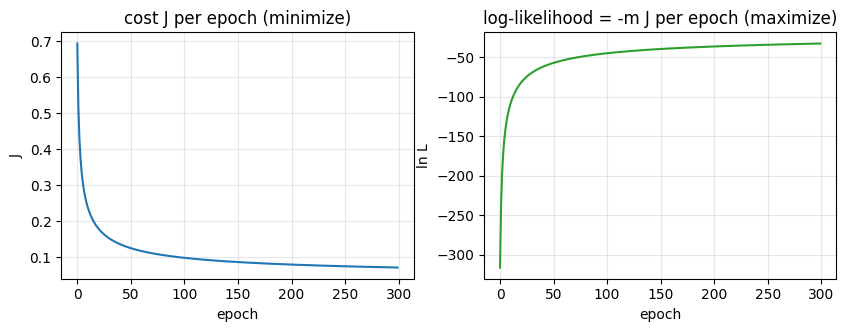

ln ℒ เพิ่มขึ้นทุก epoch: True


In [15]:
p_tr = model_np.predict_proba(X_tr)                                   # (m_tr,) = π ของทุก sample ใน train
log_lik_tr = np.sum(y_tr * np.log(p_tr) + (1 - y_tr) * np.log(1 - p_tr))
cost_tr = binary_cross_entropy(p_tr, y_tr)
print(f"ln ℒ (train) = {log_lik_tr:.4f} | −m × cost = −{len(y_tr)} × {cost_tr:.4f} = {-len(y_tr) * cost_tr:.4f} | เท่ากัน:", np.isclose(log_lik_tr, -len(y_tr) * cost_tr))
print(f"likelihood เอง = e^{log_lik_tr:.1f} ≈ {np.exp(log_lik_tr):.2e}  ← เล็กจนต้องดูใน log scale")

log_lik_curve = -len(y_tr) * np.array(model_np.history_["cost"])     # (300,) ln ℒ ต่อ epoch
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].plot(model_np.history_["cost"]); axes[0].set_title("cost J per epoch (minimize)"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("J")
axes[1].plot(log_lik_curve, c="C2"); axes[1].set_title("log-likelihood = -m J per epoch (maximize)"); axes[1].set_xlabel("epoch"); axes[1].set_ylabel("ln L")
for ax in axes: ax.grid(alpha=0.3)
plt.show()
print("ln ℒ เพิ่มขึ้นทุก epoch:", bool(np.all(np.diff(log_lik_curve) > 0)))

## ขั้นที่ 7 · threshold $\tau$: จากความน่าจะเป็นสู่คำตอบ 0/1 (สไลด์ p.58, 60)
โมเดลให้ $\pi = P(y = 1 \mid x)$ เป็นทศนิยม แต่หมอต้องการคำตอบ "ร้าย / ไม่ร้าย" จึงต้องมี **cutoff** $\tau$: ทาย 1 เมื่อ $\pi \ge \tau$
สไลด์ p.60 ใช้ $\tau = 0.5$ ซึ่งเป็นค่า default ของทุก library (`predict` ของ sklearn / `Perceptron.predict` / `TorchTrainer.predict` ล้วนใช้ 0.5) แต่ $\tau$ **ไม่ใช่ส่วนหนึ่งของการเทรน** — เปลี่ยนได้ทีหลังโดยไม่ต้องเทรนใหม่
ผลของการเปลี่ยน $\tau$ บน test set
- $\tau$ ต่ำ → ทาย positive ง่ายขึ้น → จับ malignant ได้ครบขึ้น (**recall** สูง) แต่ทาย benign เป็น malignant มากขึ้น (**precision** ต่ำ)
- $\tau$ สูง → กลับกัน

งานคัดกรองมะเร็ง การพลาดผู้ป่วยจริง (FN) แพงกว่าการเรียกมาตรวจซ้ำ (FP) จึงมักเลือก $\tau$ ต่ำกว่า 0.5 — lab10 จะกวาด $\tau$ ทุกค่าเป็น ROC curve

In [16]:
p_te = model_np.predict_proba(X_te)                                   # (m_te,) ความน่าจะเป็นจากโมเดล numpy
rows = []
for tau in [0.3, 0.5, 0.7]:
    pred = (p_te >= tau).astype(int)                                  # (m_te,) label ตาม cutoff
    assert np.array_equal(pred, model_np.predict(X_te, threshold=tau))
    rows.append({"tau": tau, **binary_report(y_te, pred)})
display(pd.DataFrame(rows).set_index("tau")[["tp", "fp", "fn", "tn", "precision", "recall", "f1", "accuracy"]].round(3))
print("τ ต่ำ → FN ลด recall ขึ้น แต่ FP เพิ่ม precision ลง | τ สูง → กลับกัน — accuracy อาจไม่เปลี่ยนแต่ 'ชนิด' ของความผิดเปลี่ยน")

# สไลด์ p.60 ใช้ τ = 0.5 กับ ŷ ของข้อมูลมะเร็งปอด (θ ชุดสาธิต)
print("\nข้อมูลมะเร็งปอด σ(z) =", Pi[0].round(3), "→ ŷ ที่ τ = 0.5 =", (Pi[0] >= 0.5).astype(int), "| y จริง =", Y_l[0].astype(int))

,tp,fp,fn,tn,precision,recall,f1,accuracy
tau,,,,,,,,
0.3,41,6,1,65,0.872,0.976,0.921,0.938
0.5,40,3,2,68,0.930,0.952,0.941,0.956
0.7,37,0,5,71,1.000,0.881,0.937,0.956


τ ต่ำ → FN ลด recall ขึ้น แต่ FP เพิ่ม precision ลง | τ สูง → กลับกัน — accuracy อาจไม่เปลี่ยนแต่ 'ชนิด' ของความผิดเปลี่ยน

ข้อมูลมะเร็งปอด σ(z) = [0.69  0.69  0.668] → ŷ ที่ τ = 0.5 = [1 1 1] | y จริง = [0 1 0]


> **หมายเหตุ errata:** สไลด์ฉบับก่อน ก.ย. 2026 (p.60) ได้ $\hat{y}$ = [0, 0, 0] เพราะใช้ $\sigma(z)$ = [0.49, 0.45, 0.45] ที่ผิด ค่าที่ถูก $\sigma(z)$ = [0.690, 0.690, 0.668] ทุกตัว $\ge 0.5$ จึงได้ $\hat{y}$ = [1, 1, 1] — $\theta$ ชุดสาธิตนี้ยังไม่ได้เทรน จึงทายผิด 2 ใน 3 ไม่ว่าจะทางไหน

## ขั้นที่ 8 · เวอร์ชัน production ใน `nnlab`
โค้ดที่เราเพิ่งเขียนใน cell ด้านบนคือ "โค้ดเพื่อความเข้าใจ" — แยกทุกขั้นให้เห็น
ในการใช้งานจริง โค้ดเดียวกันถูกจัดเป็นฟังก์ชัน/คลาสใน `src/nnlab/baselines.py` พร้อม docstring, type hints และ test
cell ถัดไปเรียกเวอร์ชัน production มาเทียบกับที่เราเขียนเอง (`SklearnLogReg` และ `TorchTrainer` ที่ใช้ interface เดียวกับ `Perceptron`) — ตัวเลขต้องตรงกัน
เปิดไฟล์ `src/nnlab/baselines.py` ควบคู่กันเพื่อดูว่าโค้ด "ทดลอง" กลายเป็นโค้ด "ใช้งานจริง" ได้อย่างไร

ทั้งสามโมเดลใน `nnlab` ทำตาม `nnlab.Classifier` protocol เดียวกัน: `fit(X, y)` → `predict_proba(X)` คืน `(m,)` → `predict(X, threshold)` คืน `(m,)` → `evaluate(X, y)` คืน dict
ประโยชน์คือเขียน loop เดียวเทรนทุกโมเดลได้ (`scripts/train.py` ใช้แบบนี้) — cell นี้วน dict ของสามโมเดลแล้วตรวจว่า shape และ `predict` สอดคล้องกับ `predict_proba >= 0.5` ทุกตัว

In [17]:
from nnlab import Classifier

torch.manual_seed(463)
models = {
    "numpy   Perceptron ": Perceptron(lr=0.1, epochs=300),
    "sklearn SklearnLogReg": SklearnLogReg(C=1.0),
    "torch   TorchTrainer": TorchTrainer(TorchPerceptron(30), loss="bce", optimizer="sgd", lr=0.1, epochs=300, batch_size=None, device="cpu"),
}
for name, mdl in models.items():
    assert isinstance(mdl, Classifier), name                      # interface เดียวกันทุกตัว
    mdl.fit(X_tr, y_tr)
    proba = mdl.predict_proba(X_te)                               # (m_te,)
    pred = mdl.predict(X_te)                                      # (m_te,) ใช้ threshold 0.5
    rep = mdl.evaluate(X_te, y_te)
    assert proba.shape == (len(y_te),) and np.array_equal(pred, (proba >= 0.5).astype(int))
    print(f"{name} | proba {proba.shape} pred {pred.shape} | accuracy {rep['accuracy']:.3f} precision {rep['precision']:.3f} recall {rep['recall']:.3f} f1 {rep['f1']:.3f}")
print("\nทุกโมเดลผ่าน interface เดียวกัน ✓ และตัวเลขตรงกับตารางขั้นที่ 5")

numpy   Perceptron  | proba (113,) pred (113,) | accuracy 0.956 precision 0.930 recall 0.952 f1 0.941
sklearn SklearnLogReg | proba (113,) pred (113,) | accuracy 0.938 precision 0.907 recall 0.929 f1 0.918


torch   TorchTrainer | proba (113,) pred (113,) | accuracy 0.965 precision 0.932 recall 0.976 f1 0.953

ทุกโมเดลผ่าน interface เดียวกัน ✓ และตัวเลขตรงกับตารางขั้นที่ 5


## ★ Key Takeaways
- perceptron ที่ใช้ sigmoid **คือ** logistic regression — numpy, scikit-learn และ PyTorch ให้โมเดลเดียวกัน ความต่างของตัวเลขมาจาก optimizer, regularization และค่าเริ่มต้น ไม่ใช่จากโมเดล
- shape ของ parameter ข้ามเครื่องมือ: `w_ (n_x, 1)` ของ numpy = `coef_.T` ของ sklearn = `nn.Linear.weight.T` ของ torch; `X @ w` (sample เป็นแถว) กับ `w.T @ X.T` (สไลด์) คือ transpose ของกัน
- autograd ของ torch (`requires_grad` → `loss.backward()`) ให้ gradient เท่ากับสูตร `dw = X @ dz.T / m` ทุกหลัก; loop ที่ init/lr/full batch เหมือน numpy ได้ parameter เท่ากันระดับ 1e-6 — จำกติกา `torch.no_grad()` ตอนอัปเดตและ `grad.zero_()` ทุกรอบ
- ใช้ `BCEWithLogitsLoss` (รับ logits) แทน `sigmoid` + `BCELoss` เพราะ $\sigma(z)$ ปัดเป็น 1.0 ใน float32 ตั้งแต่ $z$ ประมาณ 17-18 ทำให้ $\log(1 - \sigma)$ พัง
- MLE: $y \sim \text{Bernoulli}(\sigma(\theta^T x))$ → likelihood เป็นผลคูณ → log-likelihood เป็นผลบวก และ $\ln \mathcal{L} = -m\,\mathcal{J}$ ดังนั้น gradient ascent บน $\ln\mathcal{L}$ (สไลด์ p.68 บวก $\sum (y - \pi) x_j$) = gradient descent บน BCE (lab05 ลบ $dw$)
- threshold $\tau$ ไม่ใช่ส่วนหนึ่งของการเทรน: ลด $\tau$ → recall ขึ้น precision ลง; งานที่ FN แพง (คัดกรองมะเร็ง) มักเลือก $\tau < 0.5$ — lab10 จะกวาดทุก $\tau$ เป็น ROC

## แบบฝึกหัด (ทำเอง)
ส่วนนี้ต้อง**เขียนโค้ดเอง** — แต่ละข้อมี 3 cell: โจทย์ (อ่านให้จบก่อน) → cell โครง (มี `raise NotImplementedError` ให้แทนที่ด้วยโค้ดของคุณ) → cell ตรวจคำตอบ
cell ตรวจคำตอบรันได้ทันที: ถ้ายังไม่ได้ทำจะขึ้น ⏳ ถ้าผิดจะขึ้น ✗ พร้อมคำใบ้ ถ้าถูกจะขึ้น ✓ PASS
ทำได้ไม่จำกัดรอบ แก้แล้วรัน cell โครงและ cell ตรวจซ้ำ ใช้ผลจาก cell ก่อนหน้าใน lab นี้ได้ทุกตัว

In [18]:
from nnlab.exercise import check, check_close, check_shape, summary, reset
reset()   # ล้างผลการตรวจเก่าใน kernel นี้

### แบบฝึกหัด 6.1 · log-likelihood จากความน่าจะเป็นและ label
**เป้าหมาย:** เขียน `log_likelihood(p, y)` ที่คืน $\ln \mathcal{L} = \sum_i \big[y_i \ln p_i + (1 - y_i)\ln(1 - p_i)\big]$ (สไลด์ p.62) แล้วยืนยันเป็นตัวเลขว่าเท่ากับ $-m \cdot \mathcal{J}$

**ขั้นตอน**
1. `p` คือ $\pi^{(i)}$ ของทุก sample และ `y` คือ label 0/1 shape เดียวกัน — ต้องใช้ได้ทั้ง `(1, m)` (deck) และ `(m,)` (library)
2. คำนวณพจน์ในวงเล็บทีละ sample ด้วย `np.log` แล้ว `np.sum` รวมทุก sample → คืน scalar (ไม่ใช่ array)
3. ทดสอบกับ `Pi, Y_l` (มะเร็งปอด, θ สาธิต) → ต้องได้ −2.645 เท่ากับ `log_lik` ในขั้นที่ 6 และเท่ากับ `-3 * J_l`

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- บรรทัดเดียว: `np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))` — ขั้นที่ 6 คำนวณแบบนี้กับ train set ไปแล้ว
</details>

In [19]:
# --- แบบฝึกหัด 6.1: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def log_likelihood(p, y):
    """ln ℒ = Σ_i [ y_i ln p_i + (1 − y_i) ln(1 − p_i) ]  — p, y shape เดียวกัน → คืน scalar"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# print(log_likelihood(Pi, Y_l), log_lik)     # คาด −2.645 ทั้งคู่

In [20]:
# --- ตรวจคำตอบ 6.1 (รันได้ทันที ไม่ต้องแก้) ---
check_close("6.1 มะเร็งปอด ln ℒ = −2.645 (ตาราง p.63 ฉบับแก้)", lambda: log_likelihood(Pi, Y_l), -2.645, atol=1e-3, hint="y ln p + (1 − y) ln(1 − p) แล้ว np.sum")
check_close("6.1 = −m·𝒥 บนมะเร็งปอด (เทียบ nnlab.losses.binary_cross_entropy)", lambda: log_likelihood(Pi, Y_l), -3 * binary_cross_entropy(Pi, Y_l), hint="ผลรวม ไม่ใช่ค่าเฉลี่ย และ ln ℒ เป็นลบ")
check_close("6.1 = −m·𝒥 บน test set (shape (m,))", lambda: log_likelihood(p_te, y_te), -len(y_te) * binary_cross_entropy(p_te, y_te), hint="ต้องใช้ได้กับ shape (m,) ด้วย — np.sum โดยไม่ระบุ axis")
check("6.1 ln ℒ ≤ 0 เสมอ (likelihood เป็นความน่าจะเป็น ≤ 1)", lambda: log_likelihood(p_te, y_te) <= 0)

⏳ 6.1 มะเร็งปอด ln ℒ = −2.645 (ตาราง p.63 ฉบับแก้): ยังไม่ได้ทำ
⏳ 6.1 = −m·𝒥 บนมะเร็งปอด (เทียบ nnlab.losses.binary_cross_entropy): ยังไม่ได้ทำ
⏳ 6.1 = −m·𝒥 บน test set (shape (m,)): ยังไม่ได้ทำ
⏳ 6.1 ln ℒ ≤ 0 เสมอ (likelihood เป็นความน่าจะเป็น ≤ 1): ยังไม่ได้ทำ


False

### แบบฝึกหัด 6.2 · regularization ของ scikit-learn: C กับขนาดของ w
**เป้าหมาย:** เขียน `coef_norm(C)` ที่เทรน `LogisticRegression(C=C, max_iter=5000)` บน `X_tr, y_tr` แล้วคืน $\|w\|$ = `np.linalg.norm(coef_)` — เพื่อดูว่า `C` เล็ก (regularize แรง) บีบ $w$ ให้เล็ก และ `C` ใหญ่ปล่อยให้ $w$ โตบนข้อมูลที่เกือบแบ่งด้วยเส้นตรงได้

**ขั้นตอน**
1. สร้างและ `fit` `LogisticRegression(C=C, max_iter=5000)` กับ `X_tr, y_tr` (`max_iter` สูงเพื่อให้ `C=1e6` ลู่เข้าได้โดยไม่มี warning)
2. คืน `np.linalg.norm(model.coef_)` เป็น float (`coef_` shape `(1, 30)` — norm ของ matrix 1 แถวคือ norm ของ vector)
3. เพิ่มโค้ดใต้ฟังก์ชัน: พิมพ์ `coef_norm(C)` สำหรับ `C` ใน `[0.01, 1.0, 1e6]` เทียบกับ `np.linalg.norm(model_np.w_)` ของ numpy ในขั้นที่ 3 — `C` ไหนใกล้ numpy ที่สุด และทำไม `C=1e6` ถึงโตมาก (ดูคำอธิบายใต้ขั้นที่ 3)

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `LogisticRegression(C=C, max_iter=5000).fit(X_tr, y_tr).coef_` แล้วส่งเข้า `np.linalg.norm`
- numpy ที่หยุดที่ 300 epoch ได้ ‖w‖ ≈ 2.2 — อยู่ระหว่าง C=0.01 กับ C=1 คือการหยุดก่อนทำหน้าที่คล้าย regularization
</details>

In [21]:
# --- แบบฝึกหัด 6.2: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def coef_norm(C):
    """เทรน LogisticRegression(C=C, max_iter=5000) บน X_tr, y_tr → คืน ‖coef_‖ (float)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# for C in [0.01, 1.0, 1e6]:
#     print(f"C = {C:<8g} ‖w‖ = {coef_norm(C):8.3f}")
# print(f"numpy (300 epoch)  ‖w‖ = {np.linalg.norm(model_np.w_):8.3f}")

In [22]:
# --- ตรวจคำตอบ 6.2 (รันได้ทันที ไม่ต้องแก้) ---
check_close("6.2 C=1.0 ตรงกับ sk ในขั้นที่ 3 (default C=1)", lambda: coef_norm(1.0), np.linalg.norm(sk.coef_), atol=1e-4, hint="fit บน X_tr, y_tr ชุดเดียวกับขั้นที่ 3")
check_close("6.2 C=0.01 ตรงกับ nnlab.baselines.SklearnLogReg(C=0.01)", lambda: coef_norm(0.01), np.linalg.norm(SklearnLogReg(C=0.01).fit(X_tr, y_tr).w_), atol=1e-4, hint="ส่ง C เข้า LogisticRegression จริงๆ ไม่ใช่ค่าคงที่")
check("6.2 C เล็ก → ‖w‖ เล็ก: norm(0.01) < norm(1.0) < norm(1e6)", lambda: coef_norm(0.01) < coef_norm(1.0) < coef_norm(1e6), hint="C = 1/λ — C เล็กคือ regularize แรง")
check("6.2 C=1e6 (แทบไม่ regularize) ได้ ‖w‖ > 50 เพราะข้อมูลเกือบแบ่งด้วยเส้นตรงได้", lambda: coef_norm(1e6) > 50, hint="ถ้าได้ค่าเล็กหรือมี ConvergenceWarning ให้ตรวจ max_iter")

⏳ 6.2 C=1.0 ตรงกับ sk ในขั้นที่ 3 (default C=1): ยังไม่ได้ทำ
⏳ 6.2 C=0.01 ตรงกับ nnlab.baselines.SklearnLogReg(C=0.01): ยังไม่ได้ทำ
⏳ 6.2 C เล็ก → ‖w‖ เล็ก: norm(0.01) < norm(1.0) < norm(1e6): ยังไม่ได้ทำ
⏳ 6.2 C=1e6 (แทบไม่ regularize) ได้ ‖w‖ > 50 เพราะข้อมูลเกือบแบ่งด้วยเส้นตรงได้: ยังไม่ได้ทำ


False

### แบบฝึกหัด 6.3 · กวาด threshold τ: precision กับ recall
**เป้าหมาย:** เขียน `threshold_sweep(p, y, taus)` ที่คืน `(precisions, recalls)` เป็น array ยาว `len(taus)` — precision/recall เมื่อทาย 1 ที่ `p >= tau` แต่ละค่า (ขั้นที่ 7 ทำ 3 ค่า ข้อนี้ทำกี่ค่าก็ได้)

**ขั้นตอน**
1. วน `tau` ใน `taus`: สร้าง `pred = (p >= tau).astype(int)` (shape เท่า `y`)
2. หา precision และ recall ของ `pred` เทียบ `y` — ใช้ `binary_report(y, pred)` จาก `nnlab.metrics` (import แล้วในขั้นที่ 3) แล้วดึง key `"precision"`, `"recall"` หรือจะนับ TP/FP/FN เองก็ได้
3. เก็บใส่ list แล้วคืน `(np.array(precisions), np.array(recalls))`
4. เพิ่มโค้ดใต้ฟังก์ชัน: เรียกกับ `p_te, y_te` และ `taus = np.linspace(0.05, 0.95, 19)` แล้ว plot ทั้งสองเส้นเทียบ `tau` — เห็น trade-off: τ ขึ้น recall ลง

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `binary_report(y, pred)["precision"]` คือ TP / (TP + FP) และ `["recall"]` คือ TP / (TP + FN)
- `np.concatenate` ในตัวตรวจแค่ต่อสองค่าที่คืนมาเป็น array เดียว — ฟังก์ชันของคุณไม่ต้องทำ
</details>

In [23]:
# --- แบบฝึกหัด 6.3: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def threshold_sweep(p, y, taus):
    """p: ความน่าจะเป็น (m,), y: label (m,), taus: list ของ τ → (precisions (len(taus),), recalls (len(taus),))"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# taus = np.linspace(0.05, 0.95, 19)
# prec, rec = threshold_sweep(p_te, y_te, taus)
# plt.plot(taus, prec, "o-", label="precision"); plt.plot(taus, rec, "s-", label="recall")
# plt.xlabel("threshold tau"); plt.legend(); plt.grid(alpha=0.3); plt.show()

In [24]:
# --- ตรวจคำตอบ 6.3 (รันได้ทันที ไม่ต้องแก้) ---
taus_chk = np.linspace(0.05, 0.95, 19)
check_shape("6.3 precisions shape (19,)", lambda: np.asarray(threshold_sweep(p_te, y_te, taus_chk)[0]), (19,), hint="คืน tuple (precisions, recalls) อย่างละ 1 ค่าต่อ τ")
check_close("6.3 τ = 0.3, 0.5, 0.7 ตรงกับตารางขั้นที่ 7 (precision)", lambda: np.asarray(threshold_sweep(p_te, y_te, [0.3, 0.5, 0.7])[0]), [r["precision"] for r in rows], hint="pred = (p >= tau) — ใช้ >= ไม่ใช่ >")
check_close("6.3 τ = 0.3, 0.5, 0.7 ตรงกับตารางขั้นที่ 7 (recall)", lambda: np.asarray(threshold_sweep(p_te, y_te, [0.3, 0.5, 0.7])[1]), [r["recall"] for r in rows], hint="อย่าสลับลำดับ: คืน (precision, recall)")
check_close("6.3 มะเร็งปอด θ สาธิต τ = 0.5: precision 1/3, recall 1 (สไลด์ p.60 ฉบับแก้)", lambda: np.concatenate(threshold_sweep(Pi[0], Y_l[0], [0.5])), [1 / 3, 1.0], hint="ŷ = [1, 1, 1]: ที่ทายว่า 1 ถูกแค่ 1 ใน 3 แต่จับผู้ป่วยจริงได้ครบ")
check_close("6.3 τ = 0 → ทายทุกคนเป็น 1: recall = 1 และ precision = สัดส่วน positive", lambda: np.concatenate(threshold_sweep(p_te, y_te, [0.0])), [y_te.mean(), 1.0])
check("6.3 τ เพิ่ม → recall ไม่เพิ่ม (19 ค่า)", lambda: np.all(np.diff(threshold_sweep(p_te, y_te, taus_chk)[1]) <= 0), hint="τ สูงขึ้นทายเป็น 1 น้อยลง: TP ลดหรือเท่าเดิม → recall ลดหรือเท่าเดิม")

⏳ 6.3 precisions shape (19,): ยังไม่ได้ทำ
⏳ 6.3 τ = 0.3, 0.5, 0.7 ตรงกับตารางขั้นที่ 7 (precision): ยังไม่ได้ทำ
⏳ 6.3 τ = 0.3, 0.5, 0.7 ตรงกับตารางขั้นที่ 7 (recall): ยังไม่ได้ทำ
⏳ 6.3 มะเร็งปอด θ สาธิต τ = 0.5: precision 1/3, recall 1 (สไลด์ p.60 ฉบับแก้): ยังไม่ได้ทำ
⏳ 6.3 τ = 0 → ทายทุกคนเป็น 1: recall = 1 และ precision = สัดส่วน positive: ยังไม่ได้ทำ
⏳ 6.3 τ เพิ่ม → recall ไม่เพิ่ม (19 ค่า): ยังไม่ได้ทำ


False

### แบบฝึกหัด 6.4 · ตีความ w: feature ไหนมีผลต่อ odds มากที่สุด
**เป้าหมาย:** เขียน `strongest_feature(w_col, names)` ที่หา feature ที่ $|w_j|$ ใหญ่ที่สุด แล้วคืน `(j, names[j], odds_ratio)` โดย odds ratio $= e^{w_j}$ (lab05 ขั้นที่ 9) แล้วตีความบนโมเดล numpy และ sklearn

**ขั้นตอน**
1. `w_col` มี shape `(n_x, 1)` — หา index `j` ของค่าที่ `|w|` ใหญ่ที่สุดด้วย `np.argmax(np.abs(w_col))` (argmax ของ array 2 มิติ นับแบบ flatten จึงได้ int ตำแหน่งแถวพอดี)
2. odds ratio คือ `np.exp(w_col[j, 0])` — feature นั้นเพิ่มขึ้น 1 หน่วย (= 1 std เพราะ standardize แล้ว) odds ของ malignant ถูก**คูณ**ด้วยค่านี้
3. คืน `(int(j), names[j], float(odds_ratio))`
4. เพิ่มโค้ดใต้ฟังก์ชัน: เรียกกับ `model_np.w_, feature_names` และ `sk.coef_.T, feature_names` — ได้ feature เดียวกันไหม เครื่องหมายของ $w$ ตรงกันไหม

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `j = int(np.argmax(np.abs(w_col)))` แล้ว `names[j]` และ `np.exp(w_col[j, 0])`
- odds ratio > 1 แปลว่าเพิ่ม feature แล้ว odds ของ class 1 เพิ่ม; < 1 แปลว่าลด (lab05 `describe_odds`)
</details>

In [25]:
# --- แบบฝึกหัด 6.4: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def strongest_feature(w_col, names):
    """w_col: (n_x, 1), names: ชื่อ feature ยาว n_x → (j, names[j], exp(w_j)) ของ feature ที่ |w| ใหญ่ที่สุด"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# j, name, ratio = strongest_feature(model_np.w_, feature_names)
# print(f"numpy  : {name} (j={j}) w = {model_np.w_[j, 0]:+.3f} → odds ratio {ratio:.3f}")
# j2, name2, ratio2 = strongest_feature(sk.coef_.T, feature_names)
# print(f"sklearn: {name2} (j={j2}) w = {sk.coef_[0, j2]:+.3f} → odds ratio {ratio2:.3f}")

In [26]:
# --- ตรวจคำตอบ 6.4 (รันได้ทันที ไม่ต้องแก้) ---
w_abs_max = np.abs(model_np.w_).max()          # ค่าที่รู้จากโมเดล ไม่บอกว่าอยู่ตำแหน่งไหน
check("6.4 |w_j| ของ index ที่คืนมา = max |w| (numpy)", lambda: np.isclose(abs(model_np.w_[strongest_feature(model_np.w_, feature_names)[0], 0]), w_abs_max), hint="ใช้ np.abs ก่อน argmax — ไม่งั้นได้ค่าบวกสูงสุดแทนขนาดสูงสุด")
check("6.4 ชื่อ feature ตรงกับ index ที่คืนมา", lambda: strongest_feature(model_np.w_, feature_names)[1] == feature_names[strongest_feature(model_np.w_, feature_names)[0]])
check_close("6.4 odds ratio = e^{max |w|} (w_j ของโมเดลนี้เป็นบวก)", lambda: strongest_feature(model_np.w_, feature_names)[2], np.exp(w_abs_max), hint="exp ของ w_j ตัวเดียว ไม่ใช่ทั้ง vector และไม่ใช่ exp(|w_j|)")
check("6.4 odds ratio > 1: feature นี้เพิ่มขึ้น → malignant น่าจะเป็นมากขึ้น", lambda: strongest_feature(model_np.w_, feature_names)[2] > 1)
check("6.4 ใช้กับ sk.coef_.T ได้ และ w ของ feature ที่แรงที่สุดของ sklearn เป็นบวกเช่นกัน", lambda: sk.coef_[0, strongest_feature(sk.coef_.T, feature_names)[0]] > 0 and np.isclose(abs(sk.coef_[0, strongest_feature(sk.coef_.T, feature_names)[0]]), np.abs(sk.coef_).max()), hint="ฟังก์ชันต้องไม่ผูกกับ model_np — ใช้ w_col ที่รับเข้ามาเท่านั้น")

⏳ 6.4 |w_j| ของ index ที่คืนมา = max |w| (numpy): ยังไม่ได้ทำ
⏳ 6.4 ชื่อ feature ตรงกับ index ที่คืนมา: ยังไม่ได้ทำ
⏳ 6.4 odds ratio = e^{max |w|} (w_j ของโมเดลนี้เป็นบวก): ยังไม่ได้ทำ
⏳ 6.4 odds ratio > 1: feature นี้เพิ่มขึ้น → malignant น่าจะเป็นมากขึ้น: ยังไม่ได้ทำ
⏳ 6.4 ใช้กับ sk.coef_.T ได้ และ w ของ feature ที่แรงที่สุดของ sklearn เป็นบวกเช่นกัน: ยังไม่ได้ทำ


False

### สรุปผลแบบฝึกหัด
รัน cell นี้หลังทำครบทุกข้อ (รัน cell ตรวจของทุกข้อก่อน)

In [27]:
summary()

สรุป: PASS 0/19 · FAIL 0 · ยังไม่ได้ทำ 19


{'pass': 0, 'fail': 0, 'todo': 19, 'error': 0}